# 04 — Using the emulators through `cloelib`

The *Euclid* likelihood `cloelike` is built on the `cloelib` library, which exposes every emulator of this release
through its `Perturbations` protocol: a class per cosmology, an inner class per spectrum, and the same
`matter_power_spectrum(z, k)` call as the CAMB and CLASS back-ends, so the emulators are a drop-in replacement.
This notebook needs `cloelib` (and `camb` for the comparison); for the dependency-free interface see
`01_quickstart_standalone.ipynb`.

| Class | Cosmology | Inputs beyond ΛCDM | Neutrino variants (`N_mnu`) |
|---|---|---|---|
| `CosmoPowerJAXLCDMPerturbations` | ΛCDM | — | 0, 1, 2, 3 |
| `CosmoPowerJAXwCDMPerturbations` | wCDM | `w0` | 0, 1, 2, 3 |
| `CosmoPowerJAXw0waCDMPerturbations` | w0waCDM | `w0`, `wa` | 0, 1, 2, 3 |

| Inner class | Spectrum | Emulator file |
|---|---|---|
| `Linear` / `LinearCB` | linear $P_{\rm mm}$ / $P_{\rm cb}$ | `<family>[-<ν tag>]-linear.npz`, `-cb-linear.npz` |
| `NonLinear` / `NonLinearCB` | nonlinear $P_{\rm mm}$ / $P_{\rm cb}$, HMCode2020 with `log10TAGN` | `-nonlinear.npz`, `-cb-nonlinear.npz` |

Every inner class also carries `sigma8`, `fsigma8` (arrays on the requested redshifts, from the `s8-fs8` file),
`growth_factor(z, k)` and `growth_rate()`. All cosmological inputs come from the `Background` object
(`N_mnu` selects the neutrino variant, `mnu` is the mass sum, `w0`/`wa` the dark-energy parameters); the
emulator classes check that they lie inside the training box.

> The API shown here is that of `cloelib` 0.9.2.dev (October 2026). The curvature and running-index classes of
> this `cloelib` version still point at older emulator files and are being updated to the released
> `curvature-*` / `nrun-*` files, so they are not shown; use notebook `02` for those families.

Normally `cloelib` downloads the emulator files from Zenodo on first use. The first cell below points it at
the files of this repository instead.

In [1]:
import os, glob, timeit
import numpy as np
import matplotlib.pyplot as plt

import cloelib.cosmology.cosmopower_jax_cosmology as cpjc
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations
from cloelib.cosmology.cosmopower_jax_cosmology import (
    CosmoPowerJAXLCDMPerturbations,
    CosmoPowerJAXwCDMPerturbations,
    CosmoPowerJAXw0waCDMPerturbations,
)

# --- serve the emulator files from this repository instead of downloading them from Zenodo ---------------
EMU_DIR = next(p for p in ["../emulators", "emulators"] if os.path.isdir(p))
_local = {os.path.basename(p): p for p in glob.glob(os.path.join(EMU_DIR, "**", "*.npz"), recursive=True)}
_zenodo = cpjc.emulator_data

def emulator_data_from_repo(filename, zenodo_url=None):
    """Return the local copy of an emulator file if the repository has it, else fall back to cloelib's download."""
    return _local[filename] if filename in _local else _zenodo(filename, zenodo_url)

cpjc.emulator_data = emulator_data_from_repo
print(f"{len(_local)} emulator files available from {os.path.abspath(EMU_DIR)}")

plt.rcParams.update({"font.size": 11, "figure.dpi": 100})
zs = np.array([0.0, 0.5, 1.0, 2.0])
ks = np.logspace(-4, 1, 300)          # Mpc^-1

# Planck-2018-like fiducial cosmology in cloelib's Background convention
cosmo = dict(H0=67.4, Omega_b0=0.0493, Omega_cdm0=0.2642, Omega_k0=0.0, As=2.1e-9, ns=0.965,
             mnu=0.06, w0=-1.0, wa=0.0, gamma_MG=0.0, N_mnu=1)
print("setup complete")

197 emulator files available from /Users/ivan/Desktop/dr1-matter-emulators/emulators
setup complete


## 1. Linear $P(k)$: emulator versus CAMB

`CAMBBackground` holds the cosmology; the perturbation classes take it plus the redshifts at which spectra are
needed. The emulator class and the CAMB class are called identically.

Note: redshifts have been re-sorted (earliest first)


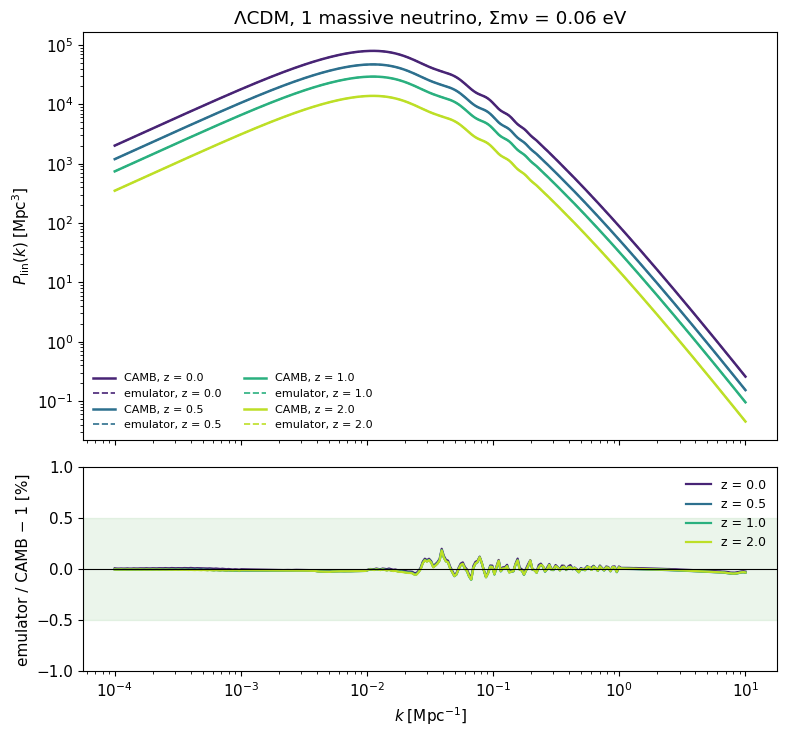

In [2]:
bg = CAMBBackground(**cosmo)
lin_camb = CAMBLinearPerturbations(background=bg, redshifts=zs)
lin_emu  = CosmoPowerJAXLCDMPerturbations.Linear(background=bg, redshifts=zs)

fig, axes = plt.subplots(2, 1, figsize=(8, 7.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(zs)))
for z, c in zip(zs, colors):
    pk_camb = np.squeeze(lin_camb.matter_power_spectrum(z, ks))
    pk_emu  = np.squeeze(lin_emu.matter_power_spectrum(z, ks))
    axes[0].loglog(ks, pk_camb, color=c, lw=1.8, label=f"CAMB, z = {z}")
    axes[0].loglog(ks, pk_emu,  color=c, lw=1.2, ls="--", label=f"emulator, z = {z}")
    axes[1].semilogx(ks, 100 * (pk_emu / pk_camb - 1), color=c, lw=1.6, label=f"z = {z}")
axes[0].set(ylabel=r"$P_{\rm lin}(k)\;[\mathrm{Mpc}^3]$", title="ΛCDM, 1 massive neutrino, Σmν = 0.06 eV"); axes[0].legend(frameon=False, fontsize=8, ncol=2)
axes[1].axhline(0, color="k", lw=0.8); axes[1].axhspan(-0.5, 0.5, color="green", alpha=0.08)
axes[1].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel="emulator / CAMB − 1 [%]", ylim=(-1, 1)); axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 2. Total matter versus CDM + baryons

`LinearCB` and `NonLinearCB` return the CDM + baryon spectrum $P_{\rm cb}$ with the same call signature.

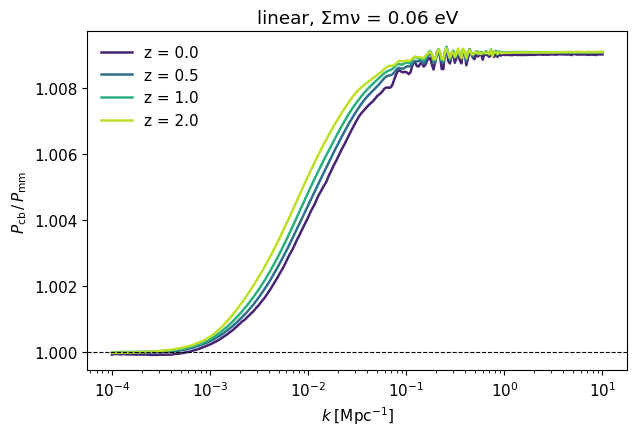

In [3]:
lin_cb = CosmoPowerJAXLCDMPerturbations.LinearCB(background=bg, redshifts=zs)
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for z, c in zip(zs, colors):
    ratio = np.squeeze(lin_cb.matter_power_spectrum(z, ks)) / np.squeeze(lin_emu.matter_power_spectrum(z, ks))
    ax.semilogx(ks, ratio, color=c, lw=1.8, label=f"z = {z}")
ax.axhline(1, color="k", lw=0.8, ls="--"); ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm cb}\,/\,P_{\rm mm}$", title="linear, Σmν = 0.06 eV")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## 3. Nonlinear spectra and baryonic feedback

`NonLinear` wraps the HMCode2020 emulator; `log10TAGN` sets the AGN feedback temperature (default 7.6 if not
given). It also takes the linear perturbations object, which it uses for the growth quantities.

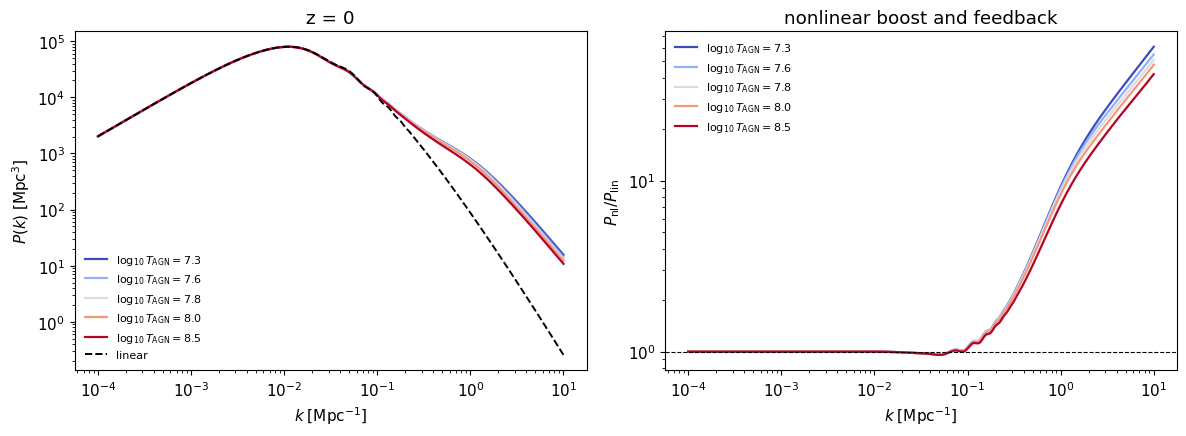

nonlinear P_cb / P_mm at z = 0, k = 1 Mpc^-1: 1.0087


In [4]:
pk_lin0 = np.squeeze(lin_emu.matter_power_spectrum(0.0, ks))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for t, c in zip([7.3, 7.6, 7.8, 8.0, 8.5], plt.cm.coolwarm(np.linspace(0, 1, 5))):
    nl = CosmoPowerJAXLCDMPerturbations.NonLinear(background=bg, linearperturbations=lin_emu, redshifts=zs, log10TAGN=t)
    pk_nl0 = np.squeeze(nl.matter_power_spectrum(0.0, ks))
    axes[0].loglog(ks, pk_nl0, color=c, lw=1.6, label=rf"$\log_{{10}}T_{{\rm AGN}} = {t}$")
    axes[1].semilogx(ks, pk_nl0 / pk_lin0, color=c, lw=1.6, label=rf"$\log_{{10}}T_{{\rm AGN}} = {t}$")
axes[0].loglog(ks, pk_lin0, "k--", lw=1.4, label="linear")
axes[0].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P(k)\;[\mathrm{Mpc}^3]$", title="z = 0"); axes[0].legend(frameon=False, fontsize=8)
axes[1].axhline(1, color="k", lw=0.8, ls="--"); axes[1].set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", ylabel=r"$P_{\rm nl}/P_{\rm lin}$", yscale="log", title="nonlinear boost and feedback")
axes[1].legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

nl_cb = CosmoPowerJAXLCDMPerturbations.NonLinearCB(background=bg, linearperturbations=lin_cb, redshifts=zs, log10TAGN=7.8)
print("nonlinear P_cb / P_mm at z = 0, k = 1 Mpc^-1:",
      f"{float(np.squeeze(nl_cb.matter_power_spectrum(0.0, np.array([1.0]))) / np.squeeze(CosmoPowerJAXLCDMPerturbations.NonLinear(background=bg, linearperturbations=lin_emu, redshifts=zs, log10TAGN=7.8).matter_power_spectrum(0.0, np.array([1.0])))):.4f}")

## 4. Dark energy: wCDM and w0waCDM

The dark-energy parameters live on the `Background` (`w0`, and `wa` for the CPL model); the matching class picks
the right emulator file. ΛCDM is recovered at $w_0 = -1$, $w_a = 0$.

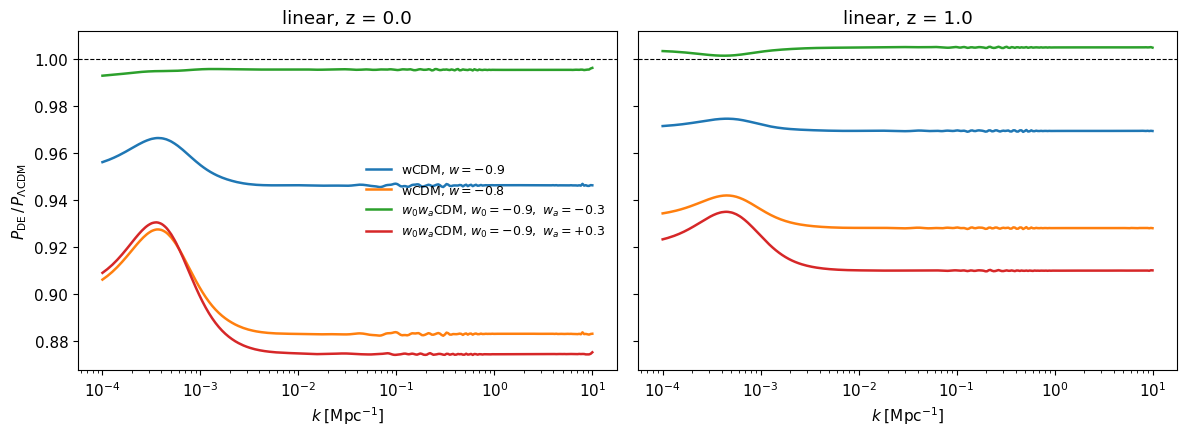

In [5]:
de_models = [
    (CosmoPowerJAXwCDMPerturbations,   dict(w0=-0.9, wa=0.0),  r"wCDM, $w=-0.9$",                  "C0"),
    (CosmoPowerJAXwCDMPerturbations,   dict(w0=-0.8, wa=0.0),  r"wCDM, $w=-0.8$",                  "C1"),
    (CosmoPowerJAXw0waCDMPerturbations, dict(w0=-0.9, wa=-0.3), r"$w_0w_a$CDM, $w_0=-0.9,\ w_a=-0.3$", "C2"),
    (CosmoPowerJAXw0waCDMPerturbations, dict(w0=-0.9, wa=0.3),  r"$w_0w_a$CDM, $w_0=-0.9,\ w_a=+0.3$", "C3"),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, z in zip(axes, [0.0, 1.0]):
    p_lcdm = np.squeeze(lin_emu.matter_power_spectrum(z, ks))
    for cls, de, lab, c in de_models:
        bg_de = CAMBBackground(**{**cosmo, **de})
        p = np.squeeze(cls.Linear(background=bg_de, redshifts=zs).matter_power_spectrum(z, ks))
        ax.semilogx(ks, p / p_lcdm, color=c, lw=1.8, label=lab)
    ax.axhline(1, color="k", lw=0.8, ls="--"); ax.set(xlabel=r"$k\;[\mathrm{Mpc}^{-1}]$", title=f"linear, z = {z}")
axes[0].set_ylabel(r"$P_{\rm DE}\,/\,P_{\Lambda{\rm CDM}}$"); axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 5. Neutrino variants, $\sigma_8(z)$, $f\sigma_8(z)$ and the growth factor

`N_mnu` on the `Background` selects the emulator variant (0: massless, 1: one massive eigenstate, 2 and 3:
degenerate eigenstates). `sigma8` and `fsigma8` are evaluated on the redshifts passed at construction;
`growth_factor(z, k)` is $\sqrt{P(k,z)/P(k,0)}$ and becomes scale-dependent with massive neutrinos.

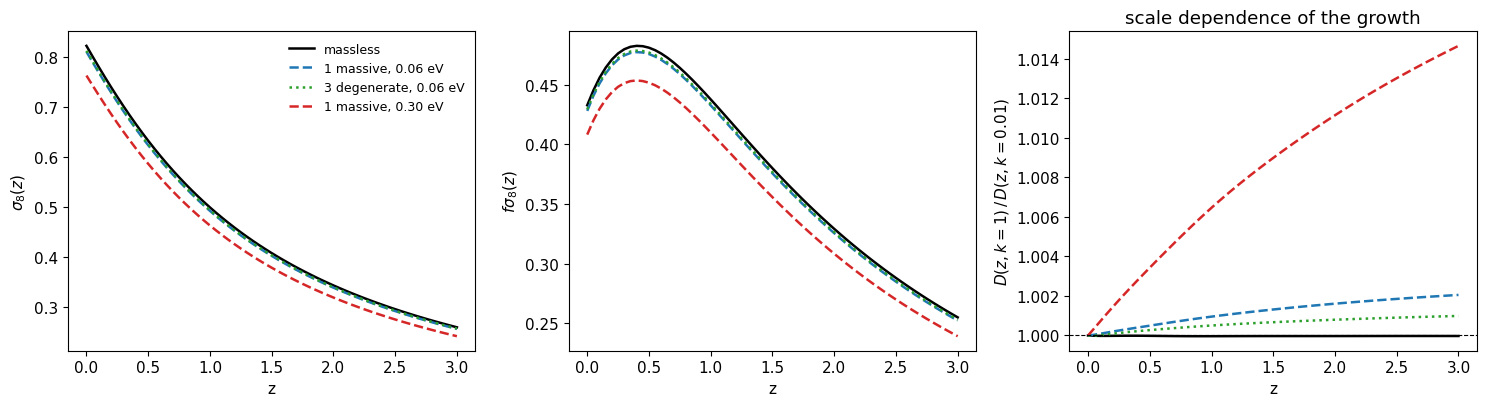

In [6]:
z_fine = np.linspace(0.0, 3.0, 61)
nu_models = [
    (dict(N_mnu=0, mnu=0.0),  r"massless",                    "k",  "-"),
    (dict(N_mnu=1, mnu=0.06), r"1 massive, 0.06 eV",          "C0", "--"),
    (dict(N_mnu=3, mnu=0.06), r"3 degenerate, 0.06 eV",       "C2", ":"),
    (dict(N_mnu=1, mnu=0.30), r"1 massive, 0.30 eV",          "C3", "--"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for pars, lab, c, ls in nu_models:
    lp = CosmoPowerJAXLCDMPerturbations.Linear(background=CAMBBackground(**{**cosmo, **pars}), redshifts=z_fine)
    axes[0].plot(z_fine, lp.sigma8,  color=c, ls=ls, lw=1.8, label=lab)
    axes[1].plot(z_fine, lp.fsigma8, color=c, ls=ls, lw=1.8, label=lab)
    D_large = np.squeeze(lp.growth_factor(z_fine, np.array([0.01])))
    D_small = np.squeeze(lp.growth_factor(z_fine, np.array([1.0])))
    axes[2].plot(z_fine, D_small / D_large, color=c, ls=ls, lw=1.8, label=lab)
axes[0].set(xlabel="z", ylabel=r"$\sigma_8(z)$"); axes[0].legend(frameon=False, fontsize=9)
axes[1].set(xlabel="z", ylabel=r"$f\sigma_8(z)$")
axes[2].axhline(1, color="k", lw=0.8, ls="--"); axes[2].set(xlabel="z", ylabel=r"$D(z, k{=}1)\,/\,D(z, k{=}0.01)$", title="scale dependence of the growth")
plt.tight_layout(); plt.show()

## 6. Timing: emulator versus CAMB

Each call rebuilds the perturbations object at the fiducial cosmology and evaluates $P(k)$ once, which is what a
likelihood does at every step. The emulator path is timed after one warm-up call (JAX compilation).

In [7]:
N_CAMB, N_EMU = 3, 20

def camb_call():
    b = CAMBBackground(**cosmo)
    CAMBLinearPerturbations(background=b, redshifts=zs).matter_power_spectrum(0.0, ks)

def emu_call():
    b = CAMBBackground(**cosmo)
    CosmoPowerJAXLCDMPerturbations.Linear(background=b, redshifts=zs).matter_power_spectrum(0.0, ks)

emu_call()
t_camb = timeit.timeit(camb_call, number=N_CAMB) / N_CAMB
t_emu  = timeit.timeit(emu_call,  number=N_EMU)  / N_EMU
print(f"CAMB (linear, 4 redshifts)           : {t_camb*1e3:8.1f} ms per call")
print(f"CosmoPower-JAX via cloelib (linear)  : {t_emu*1e3:8.1f} ms per call   (speed-up ×{t_camb/t_emu:.0f})")

Note: redshifts have been re-sorted (earliest first)


Note: redshifts have been re-sorted (earliest first)


Note: redshifts have been re-sorted (earliest first)


CAMB (linear, 4 redshifts)           :   1028.9 ms per call
CosmoPower-JAX via cloelib (linear)  :     11.3 ms per call   (speed-up ×91)


## Summary

* Through `cloelib` the emulators behave like any other back-end: build a `Background`, pick the cosmology class
  and inner class, call `matter_power_spectrum(z, k)`.
* The neutrino variant comes from `N_mnu`, the dark-energy parameters from `w0`/`wa`, feedback from `log10TAGN`.
* The emulator classes validate the inputs against the training box, unlike the bare CosmoPower-JAX interface.
* For the extended families (curvature, running, decaying dark matter, parameterised gravity) see notebooks `02`
  and `03`, which use the files directly.